# An investigation of classification methods for Diabetes 130-US Hospitals

In [1]:
!pip3 install -U ucimlrepo 

In [2]:
# Fetch the data
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_data = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_data.data.features.copy()
y = diabetes_data.data.targets.copy()

# metadata 
print(diabetes_data.metadata) 
  
# variable information 
print(diabetes_data.variables) 

/opt/anaconda3/envs/cs178/lib/python3.10/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

### Data Exploration 

In [90]:
print(f"Rows: {X.shape[0]}, Columns: {X.shape[1]}")

print("\nMissing values per column:")
missing = (X == '?').sum()
missing = missing[missing > 0]
print(missing)

print("\nClass distribution:")
print(y['readmitted'].value_counts())

Rows: 101766, Columns: 47

Missing values per column:
Series([], dtype: int64)

Class distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


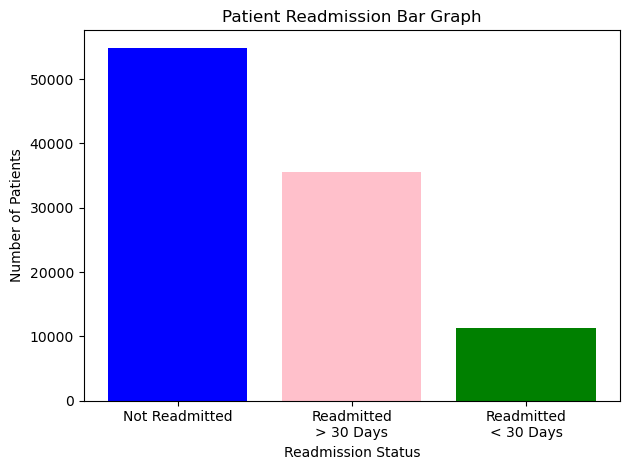

In [91]:
import matplotlib.pyplot as plt

#labels = ['Not Readmitted', 'Readmitted after more than 30 Days', 'Readmitted after less than 30 Days']
labels = ['Not Readmitted', 'Readmitted\n> 30 Days', 'Readmitted\n< 30 Days']
counts = [
    (y['readmitted'] == 'NO').sum(),
    (y['readmitted'] == '>30').sum(),
    (y['readmitted'] == '<30').sum()
]

plt.bar(labels, counts, color=['blue', 'pink', 'green'])
plt.title('Patient Readmission Bar Graph')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

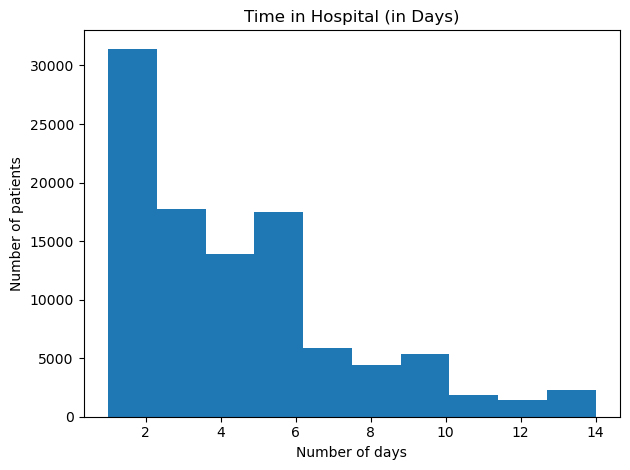

In [92]:
plt.hist(X['time_in_hospital'])
plt.title('Time in Hospital (in Days)')
plt.xlabel('Number of days')
plt.ylabel('Number of patients')
plt.tight_layout()
plt.show()

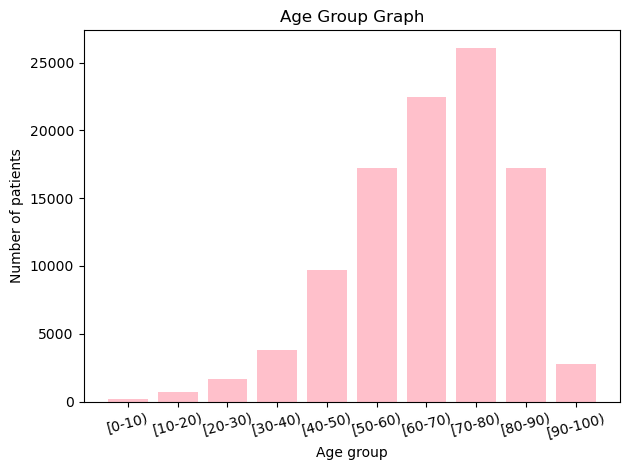

In [94]:
age_counts = X['age'].value_counts().sort_index()

plt.bar(age_counts.index, age_counts.values, color='pink')
plt.title('Age Group Graph')
plt.xlabel('Age group')
plt.ylabel('Number of patients')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

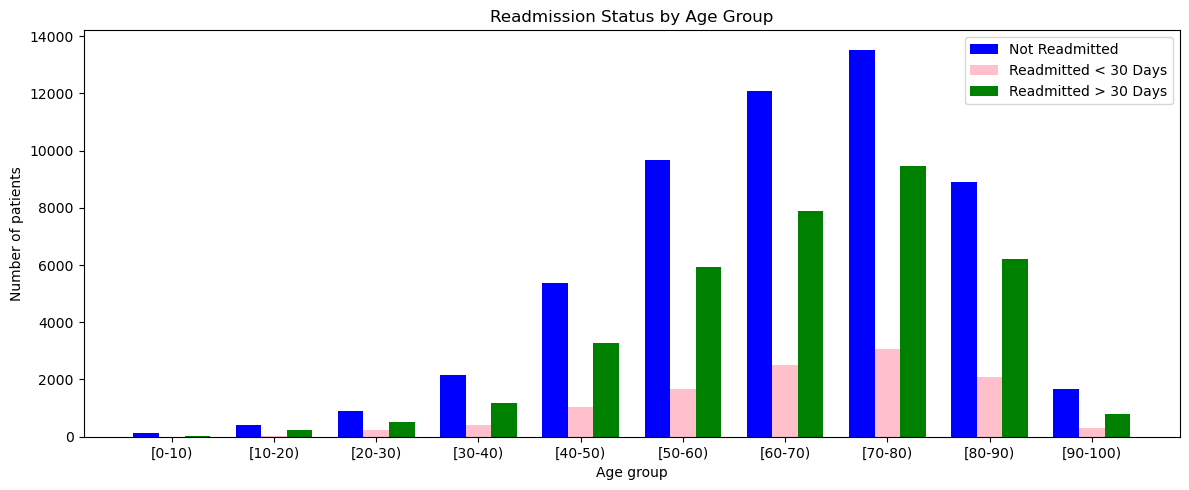

In [95]:
import numpy as np
import matplotlib.pyplot as plt

x_copy = X.copy()
x_copy['readmitted'] = y['readmitted'].values

no_readmit = x_copy[x_copy['readmitted'] == 'NO']
less_than_30_readmit = x_copy[x_copy['readmitted'] == '<30']
greater_than_30_readmit = x_copy[x_copy['readmitted'] == '>30']

age_order = sorted(x_copy['age'].unique())

no_patients = []
less_than_30_patients = []
greater_than_30_patients = []

for i in age_order:
    no_patients.append(len(no_readmit[no_readmit['age'] == i]))
    less_than_30_patients.append(len(less_than_30_readmit[less_than_30_readmit['age'] == i]))
    greater_than_30_patients.append(len(greater_than_30_readmit[greater_than_30_readmit['age'] == i]))

w, x = 0.25, np.arange(len(age_order))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, no_patients, width=w, label='Not Readmitted', color='blue')
ax.bar(x, less_than_30_patients, width=w, label='Readmitted < 30 Days', color='pink')
ax.bar(x + w, greater_than_30_patients, width=w, label='Readmitted > 30 Days', color='green')
ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.set_ylabel('Number of patients')
ax.set_xlabel('Age group')
ax.set_title('Readmission Status by Age Group')
ax.legend()
plt.tight_layout()
plt.show()

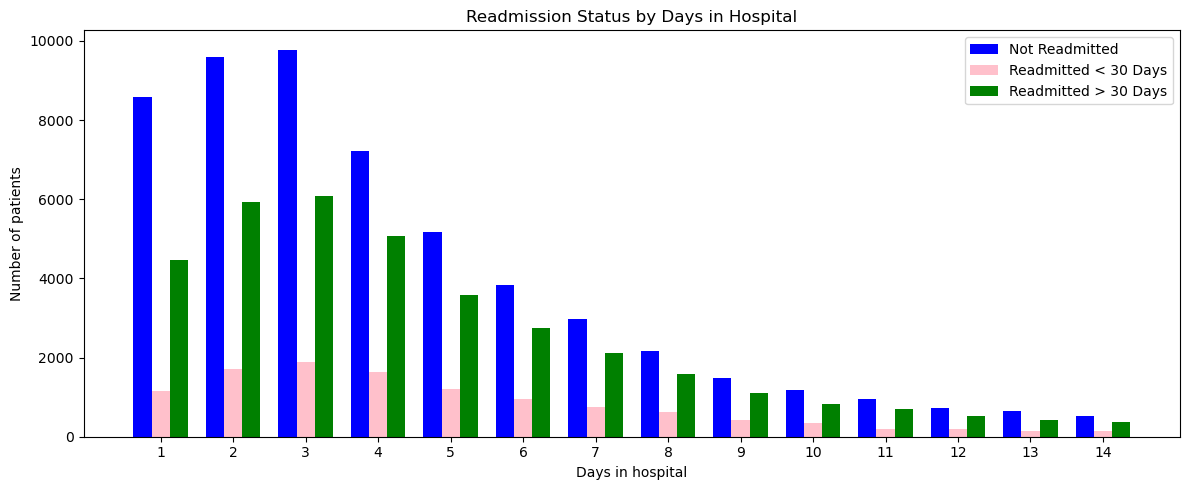

In [96]:
days = list(range(1, 15))

no_days = []
less_than_30_days = []
greater_than_30_days = []

for i in days:
    no_days.append(len(no_readmit[no_readmit['time_in_hospital'] == i]))
    less_than_30_days.append(len(less_than_30_readmit[less_than_30_readmit['time_in_hospital'] == i]))
    greater_than_30_days.append(len(greater_than_30_readmit[greater_than_30_readmit['time_in_hospital'] == i]))

w, x = 0.25, np.arange(len(days))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, no_days, width=w, label='Not Readmitted', color='blue')
ax.bar(x,less_than_30_days, width=w, label='Readmitted < 30 Days', color='pink')
ax.bar(x + w, greater_than_30_days, width=w, label='Readmitted > 30 Days', color='green')
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.set_xlabel('Days in hospital')
ax.set_ylabel('Number of patients')
ax.set_title('Readmission Status by Days in Hospital')
ax.legend()
plt.tight_layout()
plt.show()

### Feedforward Neural Networks

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt

y_binary = y['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

def run_experiment(X_data, y_data, split_ratio, handling_method):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_data, y_data, test_size=0.20, random_state=42, stratify=y_data
    )
    
    val_size = (1 - split_ratio) / 0.8
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size, random_state=42, stratify=y_train_val
    )

    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = X_train.select_dtypes(include=['object']).columns

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 128),
        activation='relu',          
        solver='adam',     
        alpha=0.01,                 
        batch_size=256,     
        learning_rate_init=0.001,
        early_stopping=True,      
        validation_fraction=0.1, 
        n_iter_no_change=10,
        random_state=42,
        max_iter=800
    )
    mlp.fit(X_train_proc, y_train)

    y_pred = mlp.predict(X_test_proc)
    # y_probs = mlp.predict_proba(X_test_proc)[:, 1] 
    # y_pred = (y_probs > 0.40).astype(int)
    
    results = {
        "Method": handling_method,
        "Split": f"{int(split_ratio*100)}/{(100-int(split_ratio*100))}",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }
    return results

def print_results(results_df):
    print("Results: \n")
    print(results_df)

    results_df.set_index(['Method', 'Split'])[['Accuracy', 'Recall']].plot(kind='bar', figsize=(10,6))
    plt.title("Comparison of Missing Value Handling and Data Splits")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
all_results = []
splits = [0.8, 0.7] 

X_imputed = X.replace('?', np.nan)
for col in X_imputed.columns:
    if X_imputed[col].dtype == 'object':
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mode()[0])
    else:
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mean())

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and replace with mean:")
    all_results.append(run_experiment(X_imputed, y_binary, s, "Replace missing data with Mean"))

X_temp = X.replace('?', np.nan)
cols_to_drop = X_temp.columns[X_temp.isnull().mean() > 0.40]
print(f"Dropping columns with too many missing values: {list(cols_to_drop)}")

X_dropped = X_temp.drop(columns=cols_to_drop).dropna()
y_dropped = y_binary.loc[X_dropped.index]

print(f"Original samples: {len(X)}, Samples remaining after row removal: {len(X_dropped)}")

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and removal method:")
    all_results.append(run_experiment(X_dropped, y_dropped, s, "Remove Missing Rows"))
    
results_df = pd.DataFrame(all_results)
print_results(results_df)

Running experiment with split 80/20 and replace with mean:
Running experiment with split 70/30 and replace with mean:
Dropping columns with too many missing values: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Original samples: 101766, Samples remaining after row removal: 59129
Running experiment with split 80/20 and removal method:
Running experiment with split 70/30 and removal method:


In [ ]:
y_binary = y['readmitted'].apply(lambda x: 1 if x != 'NO' else 0) 

all_results = []
splits = [0.8, 0.7] 

X_imputed = X.replace('?', np.nan)
for col in X_imputed.columns:
    if X_imputed[col].dtype == 'object':
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mode()[0])
    else:
        X_imputed[col] = X_imputed[col].fillna(X_imputed[col].mean())

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and replace with mean:")
    all_results.append(run_experiment(X_imputed, y_binary, s, "Replace missing data with Mean"))

X_temp = X.replace('?', np.nan)
cols_to_drop = X_temp.columns[X_temp.isnull().mean() > 0.40]
print(f"Dropping columns with too many missing values: {list(cols_to_drop)}")

X_dropped = X_temp.drop(columns=cols_to_drop).dropna()
y_dropped = y_binary.loc[X_dropped.index]

print(f"Original samples: {len(X)}, Samples remaining after row removal: {len(X_dropped)}")

for s in splits:
    print(f"Running experiment with split {int(s*100)}/{(100-int(s*100))} and removal method:")
    all_results.append(run_experiment(X_dropped, y_dropped, s, "Remove Missing Rows"))
    
results_df = pd.DataFrame(all_results)
print_results(results_df)

Running experiment with split 80/20 and replace with mean:
Running experiment with split 70/30 and replace with mean:
Dropping columns with too many missing values: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
Original samples: 101766, Samples remaining after row removal: 59129
Running experiment with split 80/20 and removal method:
Running experiment with split 70/30 and removal method:
